# Notebook 4: Maps of background meteorology

## Imports

In [1]:
import warnings
import glob
import os

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

warnings.filterwarnings("ignore")

In [2]:
out_dir = "./plots/"

## Get and prepare data

In [3]:
# Model data
path = "/work/bb1174/user/jason/hra_data/lam_hra_2025_25/*/*dyn*.nc"
ds = xr.open_mfdataset(path)

# Model grid
geo = xr.open_dataset("./data/grids/hra_DOM01.nc")

# Vertical height levels
h = xr.open_dataset(
    "./data/grids/lam_hra_2025_atm_vgrid_ml.nc", engine="netcdf4").mean("ncells").zg.rename({"height_2": "height"})

In [4]:
ds = ds.assign_coords(height=h)

In [5]:
lat = np.rad2deg(geo.clat.values)
lon = np.rad2deg(geo.clon.values)

In [6]:
# Analysis period
time_slice = slice("2025-05-29T20:00:00", "2025-05-30T06:00:00")
ds = ds.sel(time=time_slice)

In [7]:
# Colorbar positions
wind10_cbar_position = [0.92, 0.68, 0.015, 0.20]
wind1_cbar_position  = [0.92, 0.40, 0.015, 0.20]
temp_cbar_position   = [0.92, 0.12, 0.015, 0.20]

In [8]:
# Lightning data
lpath = "./data/obs/*flashes_3hr_0.1-deg_2025.nc"

In [9]:
# Load lightning data
time_slice = slice(
    "2025-05-29T18:00:00",
    "2025-05-30T12:00:00"
)

l = xr.open_mfdataset(lpath).sel(time=time_slice)

## Plot data

In [10]:
# =================================================
# SETTINGS
# =================================================

# -------------------------
# General
# -------------------------
fs = 16

# -------------------------
# Time
# -------------------------
start = np.datetime64("2025-05-30T00:00:00")
n_times = 5
time_step = np.timedelta64(1, "h")

times = start + np.arange(n_times) * time_step

# -------------------------
# Wind plots
# -------------------------
step = 500

levels_10km = 40
vmin_10km = 10
vmax_10km = 40

levels_1km = 40
vmin_1km = 10
vmax_1km = 30

# -------------------------
# Surface temperature
# -------------------------
levels_ta = 30
vmin_ta = 5
vmax_ta = 30
cmap_ta = "RdYlBu_r"

# -------------------------
# Wind vectors
# -------------------------
qscale = 800
qwidth = 0.0025

# -------------------------
# Heights
# -------------------------
height_10km = 10000
height_1km = 1000

lowest_height = ds.height.min()

# -------------------------
# Lightning
# -------------------------
lightning_threshold = 0

# -------------------------
# Map
# -------------------------
map_extent = [
    lon.min(),
    lon.max(),
    lat.min(),
    lat.max(),
]

# -------------------------
# Figure
# -------------------------
n_rows = 3
n_cols = len(times)

figsize = (20, 11)

# -------------------------
# Output
# -------------------------
output_filename = "background_meteo.png"
output_dpi = 300

# -------------------------
# Colorbar positions
# -------------------------
cbar_10km_position = [0.92, 0.68, 0.015, 0.20]
cbar_1km_position  = [0.92, 0.40, 0.015, 0.20]
cbar_ta_position   = [0.92, 0.12, 0.015, 0.20]

# -------------------------
# Figure layout
# -------------------------
figure_left = 0.05
figure_right = 0.88
figure_bottom = 0.08
figure_top = 0.92
figure_wspace = 0.05
figure_hspace = 0.01

# -------------------------
# Map features
# -------------------------
map_resolution = "50m"
map_linewidth = 0.8
state_linewidth = 0.5

# -------------------------
# Lightning markers
# -------------------------
lightning_size = 25
lightning_marker = "x"

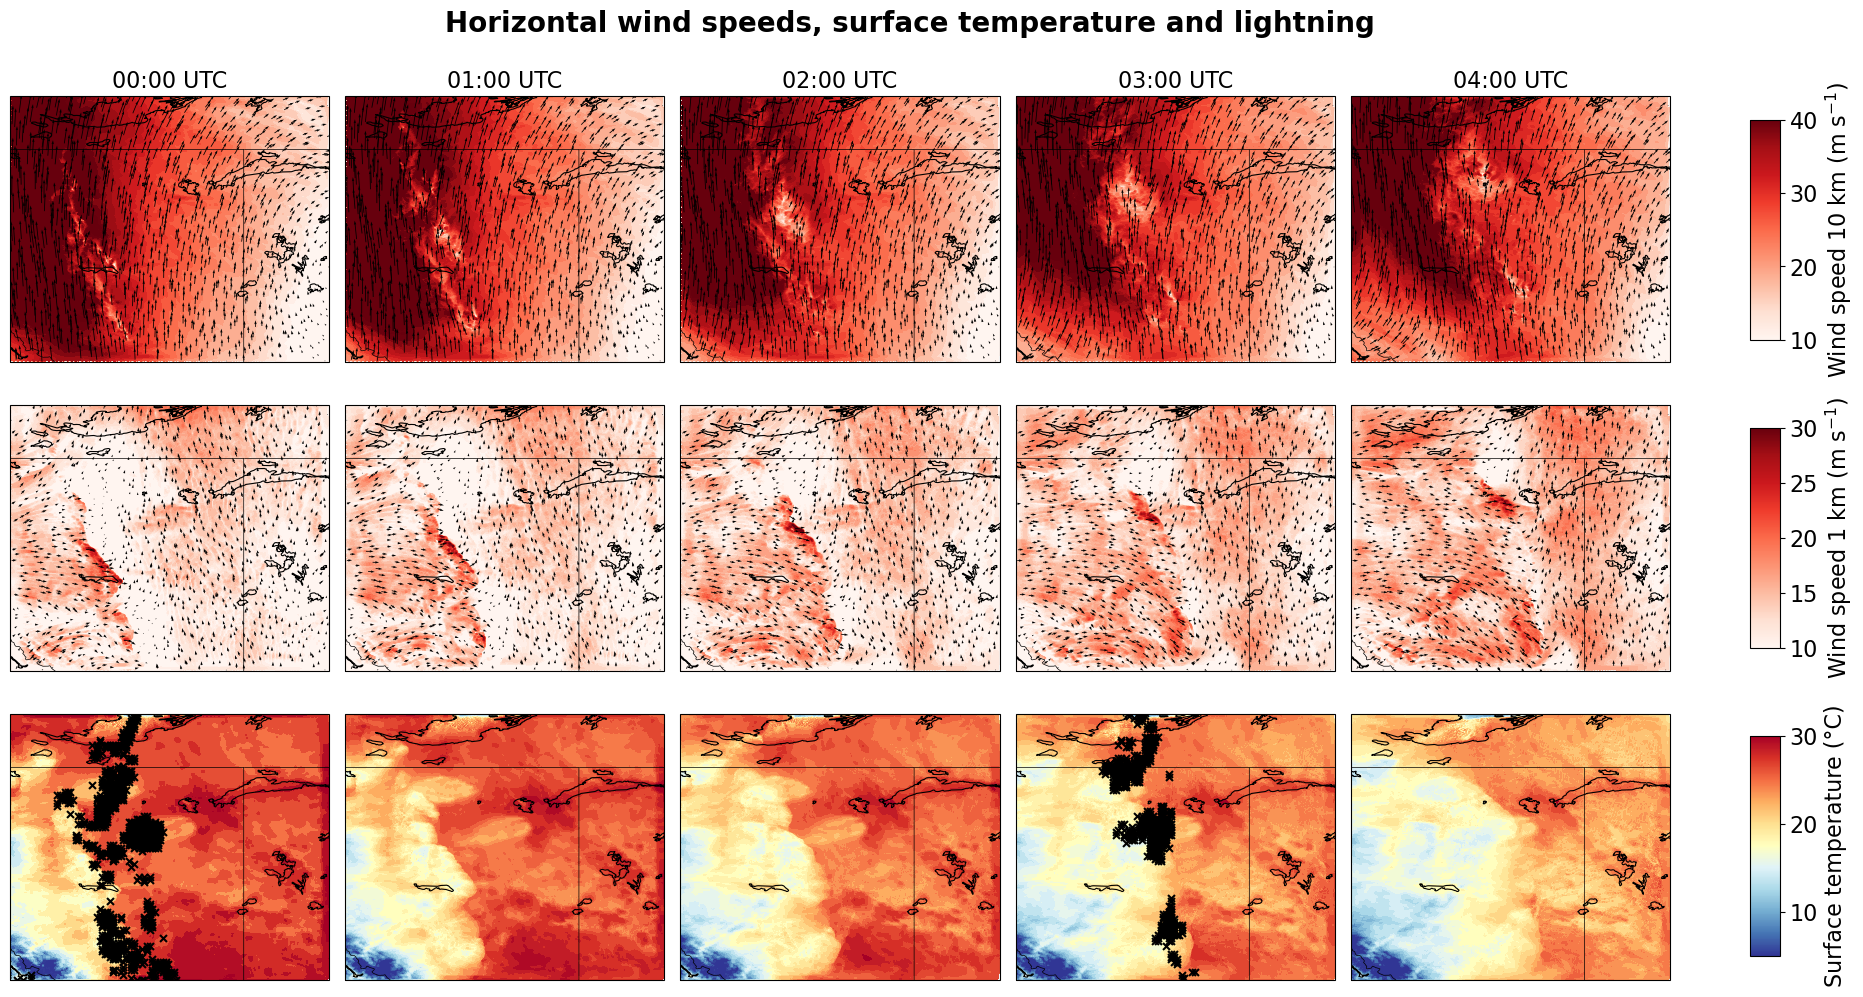

In [11]:



# =================================================
# HELPER FUNCTIONS
# =================================================

def add_map_features(ax):
    """Add common map features."""

    ax.add_feature(
        cfeature.LAKES,
        facecolor="none",
        edgecolor="black",
        linewidth=map_linewidth
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=map_linewidth
    )

    ax.coastlines(
        linewidth=map_linewidth
    )

    shpfilename = shpreader.natural_earth(
        resolution=map_resolution,
        category="cultural",
        name="admin_1_states_provinces_lines"
    )

    for record in shpreader.Reader(shpfilename).records():

        ax.add_geometries(
            [record.geometry],
            ccrs.PlateCarree(),
            facecolor="none",
            edgecolor="black",
            linewidth=state_linewidth
        )

    ax.set_extent(
        map_extent,
        crs=ccrs.PlateCarree()
    )


def add_colorbar(position, cmap, vmin, vmax, label):

    cax = fig.add_axes(position)

    sm = ScalarMappable(
        norm=Normalize(vmin=vmin, vmax=vmax),
        cmap=cmap
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        cax=cax
    )

    cbar.set_label(
        label,
        fontsize=fs
    )

    cbar.ax.tick_params(
        labelsize=fs
    )


# =================================================
# LIGHTNING GRID
# =================================================

lon2d, lat2d = np.meshgrid(
    l.lon.values,
    l.lat.values
)


# =================================================
# FIGURE
# =================================================

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=figsize,
    sharex=True,
    sharey=True,
    subplot_kw={
        "projection": ccrs.PlateCarree()
    }
)


# =================================================
# LOOP OVER TIMES
# =================================================

for col, my_time in enumerate(times):

    # -------------------------
    # Model state
    # -------------------------
    myset = ds.sel(
        time=my_time,
        method="nearest"
    )


    # =================================================
    # 10 KM WIND
    # =================================================

    ax = axes[0, col]

    add_map_features(ax)

    wind = myset.sel(
        height=height_10km,
        method="nearest"
    )

    speed = np.sqrt(
        wind.ua**2 + wind.va**2
    )

    ax.tricontourf(
        lon,
        lat,
        speed,
        levels=levels_10km,
        cmap="Reds",
        vmin=vmin_10km,
        vmax=vmax_10km,
        extend="both",
        transform=ccrs.PlateCarree()
    )

    ax.quiver(
        lon[::step],
        lat[::step],
        wind.ua[::step],
        wind.va[::step],
        color="k",
        scale=qscale,
        width=qwidth,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(
        pd.to_datetime(
            str(my_time)
        ).strftime("%H:%M UTC"),
        fontsize=fs
    )

    if col == 0:
        ax.set_ylabel(
            "10 km\nLatitude",
            fontsize=fs
        )


    # =================================================
    # 1 KM WIND
    # =================================================

    ax = axes[1, col]

    add_map_features(ax)

    wind = myset.sel(
        height=height_1km,
        method="nearest"
    )

    speed = np.sqrt(
        wind.ua**2 + wind.va**2
    )

    ax.tricontourf(
        lon,
        lat,
        speed,
        levels=levels_1km,
        cmap="Reds",
        vmin=vmin_1km,
        vmax=vmax_1km,
        extend="both",
        transform=ccrs.PlateCarree()
    )

    ax.quiver(
        lon[::step],
        lat[::step],
        wind.ua[::step],
        wind.va[::step],
        color="k",
        scale=qscale,
        width=qwidth,
        transform=ccrs.PlateCarree()
    )

    if col == 0:
        ax.set_ylabel(
            "1 km\nLatitude",
            fontsize=fs
        )


    # =================================================
    # SURFACE TEMPERATURE
    # =================================================

    ax = axes[2, col]

    add_map_features(ax)

    ax.tricontourf(
        lon,
        lat,
        myset.sel(
            height=lowest_height,
            method="nearest"
        ).ta - 273.15,
        levels=levels_ta,
        cmap=cmap_ta,
        vmin=vmin_ta,
        vmax=vmax_ta,
        extend="both",
        transform=ccrs.PlateCarree()
    )


    # =================================================
    # LIGHTNING
    # =================================================

    if my_time in l.time.values:

        flash = (l.cg_flashes + l.cc_flashes).sel(
            time=my_time
        )

        mask = flash.values > lightning_threshold

        ax.scatter(
            lon2d[mask],
            lat2d[mask],
            s=lightning_size,
            marker=lightning_marker,
            color="black",
            transform=ccrs.PlateCarree(),
            zorder=100
        )

    if col == 0:

        ax.set_ylabel(
            f"{float(lowest_height.values) / 1000:.1f} km\nLatitude",
            fontsize=fs
        )


# =================================================
# AXIS LABELS
# =================================================

for ax in axes.flat:

    ax.tick_params(
        labelsize=fs
    )


for ax in axes[-1, :]:

    ax.set_xlabel(
        "Longitude",
        fontsize=fs
    )


# =================================================
# COLORBARS
# =================================================

add_colorbar(
    cbar_10km_position,
    "Reds",
    vmin_10km,
    vmax_10km,
    "Wind speed 10 km (m s$^{-1}$)"
)

add_colorbar(
    cbar_1km_position,
    "Reds",
    vmin_1km,
    vmax_1km,
    "Wind speed 1 km (m s$^{-1}$)"
)

add_colorbar(
    cbar_ta_position,
    cmap_ta,
    vmin_ta,
    vmax_ta,
    "Surface temperature (°C)"
)


# =================================================
# TITLE
# =================================================

fig.suptitle(
    "Horizontal wind speeds, surface temperature and lightning",
    fontsize=fs + 4,
    fontweight="bold"
)


# =================================================
# LAYOUT
# =================================================

fig.subplots_adjust(
    left=figure_left,
    right=figure_right,
    bottom=figure_bottom,
    top=figure_top,
    wspace=figure_wspace,
    hspace=figure_hspace
)


# =================================================
# SAVE + SHOW
# =================================================

fig.savefig(
    out_dir + output_filename,
    dpi=output_dpi,
    bbox_inches="tight"
)

plt.show()